## generate_synthetic_credit_data

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 20000  # number of applicants

# Basic demographics
age = np.random.randint(21, 70, size=n)
income = np.random.normal(65000, 20000, size=n).clip(20000, 200000)
employment_length = np.random.randint(0, 25, size=n)  # years

# Credit profile
credit_score = np.random.normal(680, 70, size=n).clip(480, 830)
dti = np.random.normal(0.32, 0.12, size=n).clip(0.05, 0.75)   # Debt-to-income ratio
utilization = np.random.normal(0.45, 0.2, size=n).clip(0.0, 0.98)
num_delinquencies_12m = np.random.poisson(0.3, size=n)
recent_bankruptcy = np.random.binomial(1, 0.05, size=n)

# Loan characteristics
loan_amount = np.random.normal(15000, 7000, size=n).clip(2000, 50000)
term_months = np.random.choice([36, 60], size=n, p=[0.6, 0.4])
channel = np.random.choice(["Online", "Branch", "Partner"], size=n, p=[0.6, 0.25, 0.15])
product_type = np.random.choice(["Personal Loan", "Auto Refi", "Debt Consolidation"],
                                size=n, p=[0.5, 0.25, 0.25])

# Build an underlying probability of default (PD) using a logistic function
# Lower credit score, higher DTI, more delinquencies, recent BK -> higher PD
from scipy.special import expit

# Normalize some features
cs_norm = (720 - credit_score) / 100.0   # higher when score is worse
dti_norm = (dti - 0.3) * 2               # centered around 0
util_norm = (utilization - 0.4) * 1.5
delinq_norm = num_delinquencies_12m
bk_norm = recent_bankruptcy

log_odds = (
    -2.0
    + 1.2 * cs_norm
    + 1.1 * dti_norm
    + 0.8 * util_norm
    + 0.5 * delinq_norm
    + 1.5 * bk_norm
)

pd_true = expit(log_odds)  # between 0 and 1

default_12m = np.random.binomial(1, pd_true)

# Simple interest rate depending on risk
base_rate = 0.08
risk_spread = (pd_true - pd_true.mean()) * 0.4  # +/- spread
interest_rate = (base_rate + risk_spread).clip(0.05, 0.25)

df = pd.DataFrame({
    "applicant_id": np.arange(1, n + 1),
    "age": age,
    "income": income.round(2),
    "employment_length_years": employment_length,
    "credit_score": credit_score.round(0),
    "dti": dti.round(3),
    "utilization": utilization.round(3),
    "num_delinquencies_12m": num_delinquencies_12m,
    "recent_bankruptcy": recent_bankruptcy,
    "loan_amount": loan_amount.round(2),
    "term_months": term_months,
    "interest_rate": (interest_rate * 100).round(2),  # percent
    "channel": channel,
    "product_type": product_type,
    "default_12m": default_12m
})

df.head()

,applicant_id,age,income,employment_length_years,credit_score,dti,utilization,num_delinquencies_12m,recent_bankruptcy,loan_amount,term_months,interest_rate,channel,product_type,default_12m
0,1,59,61972.52,12,668.0,0.469,0.445,0,1,10985.80,60,22.60,Online,Personal Loan,0
1,2,49,55828.97,17,515.0,0.420,0.722,1,0,13529.03,36,25.00,Online,Personal Loan,0
2,3,35,90001.29,12,721.0,0.364,0.683,1,0,9453.48,60,7.74,Branch,Personal Loan,1
3,4,63,59497.59,12,671.0,0.357,0.225,1,0,10428.33,36,7.94,Online,Debt Consolidation,0
4,5,28,52615.20,6,622.0,0.297,0.536,1,0,7432.95,60,15.57,Online,Debt Consolidation,0


In [ ]:
import os
os.makedirs("../data/raw", exist_ok=True)
df.to_csv("../data/raw/credit_applications.csv", index=False)
print("Saved to ../data/raw/credit_applications.csv with shape:", df.shape)

Saved to ../data/raw/credit_applications.csv with shape: (20000, 15)


## model_PD_and_SHAP.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

import shap

# Load data
df = pd.read_csv("../data/raw/credit_applications.csv")

# Features & target
target = "default_12m"
numeric_features = [
    "age", "income", "employment_length_years", "credit_score",
    "dti", "utilization", "num_delinquencies_12m",
    "loan_amount", "term_months", "interest_rate"
]
categorical_features = ["channel", "product_type"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Preprocess
numeric_transformer = "passthrough"
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Model
gb_clf = GradientBoostingClassifier(random_state=42)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gb_clf)
])

clf.fit(X_train, y_train)

# Predict PD
y_pred_proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("Test AUC:", round(auc, 3))
print(classification_report(y_test, (y_pred_proba > 0.2).astype(int)))


Test AUC: 0.733
              precision    recall  f1-score   support

           0       0.86      0.56      0.68      4365
           1       0.40      0.76      0.52      1635

    accuracy                           0.62      6000
   macro avg       0.63      0.66      0.60      6000
weighted avg       0.74      0.62      0.64      6000



/tmp/ipython-input-3313804182.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


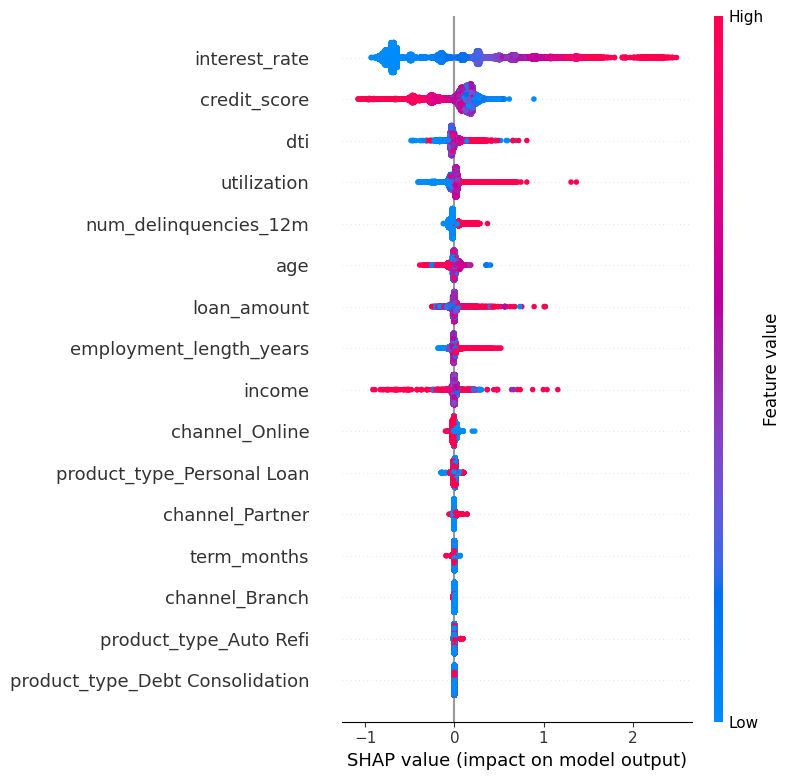

In [ ]:
# Extract the underlying trained model & encoded data for SHAP
X_train_transformed = clf.named_steps["preprocessor"].transform(X_train)
model = clf.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed)

# Feature names after encoding
ohe = clf.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_names

# Summary plot (works in notebooks)
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


Save predicted PDs

In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
X_test_copy = X_test.copy()
X_test_copy["default_12m"] = y_test.values
X_test_copy["pd_model"] = y_pred_proba
X_test_copy["applicant_id"] = df.loc[X_test.index, "applicant_id"].values

X_test_copy.to_csv("../data/processed/credit_with_pd_testset.csv", index=False)

## 03_strategy_AB_test_simulation

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/processed/credit_with_pd_testset.csv")

# ----- Strategy A: Rule-based “current” underwriting -----
def apply_strategy_A(row):
    if (
        row["credit_score"] >= 640
        and row["dti"] <= 0.4
        and row["num_delinquencies_12m"] <= 1
        and row.get("recent_bankruptcy", 0) == 0
    ):
        return 1  # approved
    else:
        return 0  # declined

# If we don't have recent_bankruptcy in this file, merge from raw:
raw = pd.read_csv("../data/raw/credit_applications.csv")[["applicant_id", "recent_bankruptcy"]]
df = df.merge(raw, on="applicant_id", how="left")

df["approved_A"] = df.apply(apply_strategy_A, axis=1)

# ----- Strategy B: Model-based with PD threshold -----
PD_THRESHOLD = 0.18  # you can tune this

df["approved_B"] = (df["pd_model"] <= PD_THRESHOLD).astype(int)

# ----- Simulate assignment to Champion/Challenger (A/B) -----
np.random.seed(42)
df["strategy_group"] = np.random.choice(["A", "B"], size=len(df))

df["approved_AB"] = np.where(
    df["strategy_group"] == "A",
    df["approved_A"],
    df["approved_B"]
)

# ----- Economic assumptions -----
LGD = 0.6  # loss given default (60%)
MARGIN = 0.12  # annualized interest margin as % of balance

# Approx profit: interest margin - expected loss
df["expected_loss"] = df["loan_amount"] * LGD * df["default_12m"]
df["interest_income"] = df["loan_amount"] * MARGIN
df["profit"] = np.where(df["approved_AB"] == 1,
                        df["interest_income"] - df["expected_loss"],
                        0.0)

# ----- KPI calculations -----
def strategy_metrics(df_subset, flag_col):
    total_apps = len(df_subset)
    approvals = df_subset[flag_col].sum()
    approval_rate = approvals / total_apps

    # Only on approved loans
    approved_loans = df_subset[df_subset[flag_col] == 1]
    if len(approved_loans) == 0:
        return {
            "total_apps": total_apps,
            "approval_rate": approval_rate,
            "default_rate_approved": np.nan,
            "avg_profit_per_approved": np.nan,
            "total_profit": 0.0
        }

    default_rate_approved = approved_loans["default_12m"].mean()
    avg_profit_per_approved = approved_loans["profit"].mean()
    total_profit = approved_loans["profit"].sum()

    return {
        "total_apps": total_apps,
        "approval_rate": approval_rate,
        "default_rate_approved": default_rate_approved,
        "avg_profit_per_approved": avg_profit_per_approved,
        "total_profit": total_profit
    }

metrics_A = strategy_metrics(df, "approved_A")
metrics_B = strategy_metrics(df, "approved_B")
metrics_AB_A = strategy_metrics(df[df["strategy_group"] == "A"], "approved_AB")
metrics_AB_B = strategy_metrics(df[df["strategy_group"] == "B"], "approved_AB")

metrics_A, metrics_B, metrics_AB_A, metrics_AB_B


({'total_apps': 6000,
  'approval_rate': np.float64(0.4886666666666667),
  'default_rate_approved': np.float64(0.1664392905866303),
  'avg_profit_per_approved': np.float64(390.1493529331514),
  'total_profit': np.float64(1143917.9028)},
 {'total_apps': 6000,
  'approval_rate': np.float64(0.444),
  'default_rate_approved': np.float64(0.1313813813813814),
  'avg_profit_per_approved': np.float64(567.531045945946),
  'total_profit': np.float64(1511902.7064)},
 {'total_apps': 3018,
  'approval_rate': np.float64(0.48740888005301525),
  'default_rate_approved': np.float64(0.1699524133242692),
  'avg_profit_per_approved': np.float64(297.5264687967369),
  'total_profit': np.float64(437661.43559999997)},
 {'total_apps': 2982,
  'approval_rate': np.float64(0.44299128101945),
  'default_rate_approved': np.float64(0.13171839515518546),
  'avg_profit_per_approved': np.float64(593.242552006056),
  'total_profit': np.float64(783673.4112)})

# Simple statistical comparison (A/B)

In [ ]:
from scipy import stats

# Compare default rates for approved loans
grpA = df[(df["strategy_group"] == "A") & (df["approved_AB"] == 1)]["default_12m"]
grpB = df[(df["strategy_group"] == "B") & (df["approved_AB"] == 1)]["default_12m"]

t_stat, p_val = stats.ttest_ind(grpA, grpB, equal_var=False)
print("T-test default rate A vs B: p-value =", p_val)

# Compare profit per approved loan
grpA_prof = df[(df["strategy_group"] == "A") & (df["approved_AB"] == 1)]["profit"]
grpB_prof = df[(df["strategy_group"] == "B") & (df["approved_AB"] == 1)]["profit"]

t_stat2, p_val2 = stats.ttest_ind(grpA_prof, grpB_prof, equal_var=False)
print("T-test profit per approved A vs B: p-value =", p_val2)


T-test default rate A vs B: p-value = 0.004697274349618032
T-test profit per approved A vs B: p-value = 0.030380040493980954


In [ ]:
# Export for Power BI/dashboard

df.to_csv("../data/processed/credit_strategy_experiment_AB.csv", index=False)
print("Exported file for dashboard.")

Exported file for dashboard.
